
Running GA with num_bits=10
generation 0: Best = 1111001110 (974) - Fitness: 948676
generation 1: Best = 1111001110 (974) - Fitness: 948676
generation 2: Best = 1111101110 (1006) - Fitness: 1012036
generation 3: Best = 1111101110 (1006) - Fitness: 1012036
generation 4: Best = 1111101110 (1006) - Fitness: 1012036
generation 5: Best = 1111111010 (1018) - Fitness: 1036324
generation 6: Best = 1111111110 (1022) - Fitness: 1044484
generation 7: Best = 1111111110 (1022) - Fitness: 1044484
generation 8: Best = 1111111110 (1022) - Fitness: 1044484
generation 9: Best = 1111111110 (1022) - Fitness: 1044484
generation 10: Best = 1111111111 (1023) - Fitness: 1046529
Target fitness 1046529 reached at generation 10.
Final best solution found (10-bit): 1111111111 (1023) with fitness: 1046529

Running GA with num_bits=20
generation 0: Best = 11110011000100010010 (995602) - Fitness: 991223342404
generation 1: Best = 11110011000100101110 (995630) - Fitness: 991279096900
generation 2: Best = 11110011001

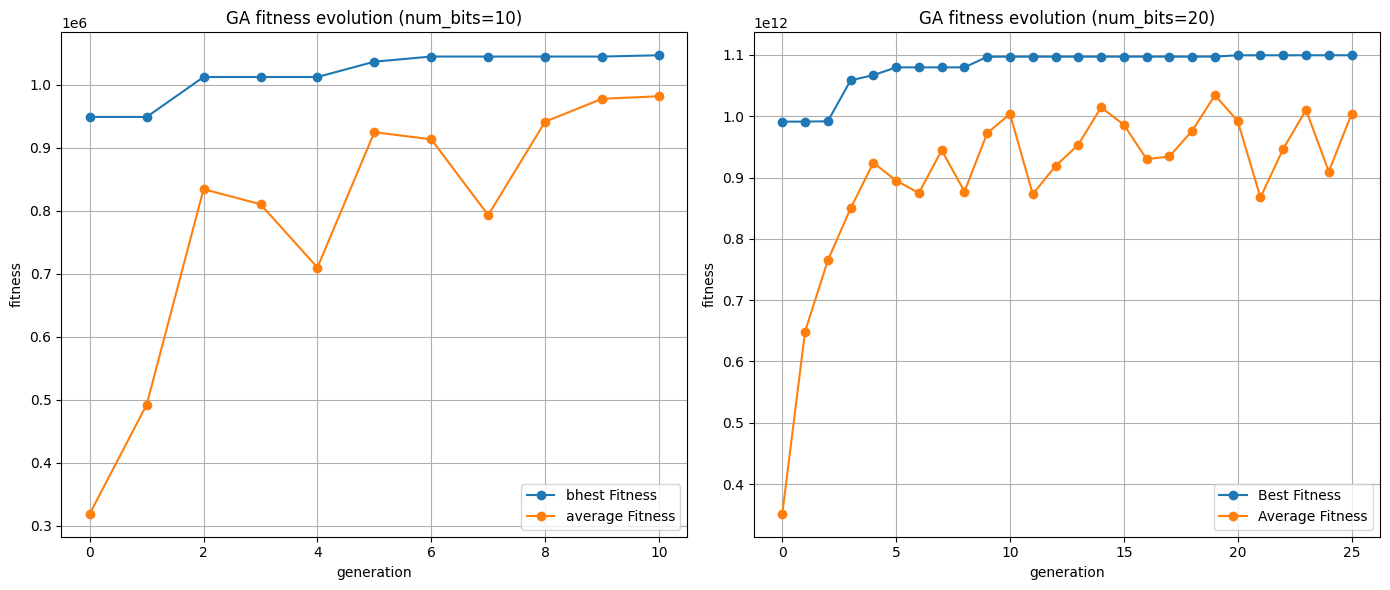

fitness history plots generated.


In [8]:
###question-
'''
1. Fitness based selection
2. 2 point crossover
3. plot best fitness and average fitness vs iteration in 2 sub plots
4. change the number of bits representation and check for any variation in convergence
5. instead of limiting the generation use some stopping criterion for stopping the
iteration

'''



import random
import numpy as np
import matplotlib.pyplot as plt

#the fitness function --- here x**2 or x square
def fitness(x):
    return x ** 2

#binary string to integer
def binary_to_decimal(binary):
    return int(binary, 2)

#generate a random individual with configurable bit lengt
def random_individual(num_bits):
    return ''.join(random.choice('01') for _ in range(num_bits))

#generate an initial population with configurable bit lengt
def generate_population(size, num_bits):
    return [random_individual(num_bits) for _ in range(size)]

#select two parents using fitness-based selection PART 1 of Q
def select_parents(population):
    fitness_scores = [fitness(binary_to_decimal(individual)) for individual in population]
    if sum(fitness_scores) == 0:
        weights = [1] * len(population)
    else:
        weights = fitness_scores
    return random.choices(population, weights=weights, k=2)

#2-point crossover PART 2 of Q
def crossover(parent1, parent2):
    length = len(parent1)
    if length < 3:
        return parent1, parent2

    point1 = random.randint(1, length - 2)
    point2 = random.randint(point1 + 1, length - 1)

    child1 = parent1[:point1] + parent2[point1:point2] + parent1[point2:]
    child2 = parent2[:point1] + parent1[point1:point2] + parent2[point2:]
    return child1, child2

#perform mutation with a given probability
#you can alter the mutation rate here itself----
def mutate(individual, mutation_rate=0.1):
    new_individual = ''.join(
        bit if random.random() > mutation_rate else str(1 - int(bit))
        for bit in individual
    )
    return new_individual

#ruun the Genetic Algorithm (updated for using both num_bits and convergence-based stopping)
#parameters inputed-  population size, no. of genration,s mutation rate, num_bits, target of fitness, patience genrations number
def genetic_algorithm(pop_size, generations, mutation_rate, num_bits, target_fitness, patience_generations):
    population = generate_population(pop_size, num_bits)

    best_fitness_history = []
    avg_fitness_history = []

    best_overall_fitness = -np.inf
    generations_without_improvement = 0

    for generation in range(generations):
        current_fitness_scores = [fitness(binary_to_decimal(individual)) for individual in population]

        best_fitness_current_gen = max(current_fitness_scores)
        avg_fitness_current_gen = np.mean(current_fitness_scores)

        best_fitness_history.append(best_fitness_current_gen)
        avg_fitness_history.append(avg_fitness_current_gen)

        print(f"generation {generation}: Best = {max(population, key=lambda x: fitness(binary_to_decimal(x)))} ({binary_to_decimal(max(population, key=lambda x: fitness(binary_to_decimal(x))))}) - Fitness: {best_fitness_current_gen}")

        # Convergence-based stopping criteria
        if target_fitness is not None and best_fitness_current_gen >= target_fitness:
            print(f"Target fitness {target_fitness} reached at generation {generation}.")
            break

        if best_fitness_current_gen > best_overall_fitness:
            best_overall_fitness = best_fitness_current_gen
            generations_without_improvement = 0
        else:
            generations_without_improvement += 1

        if generations_without_improvement >= patience_generations:
          #  patience_genration is   PART 5 of Q
            print(f"Best fitness has not improved for {patience_generations} generations. hence stopping.")
            break

        population = sorted(population, key=lambda x: fitness(binary_to_decimal(x)), reverse=True)

        new_population = population[:2]  #eliteism: Keep the best two from genration

        while len(new_population) < pop_size:
            parent1, parent2 = select_parents(population)
            child1, child2 = crossover(parent1, parent2)
            new_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])

        population = new_population[:pop_size]

    final_best_individual = max(population, key=lambda x: fitness(binary_to_decimal(x)))
    return final_best_individual, best_fitness_history, avg_fitness_history

##PART 3,4 of Q-- using 10 bit and 20 bit and plotting graphs
#run the genetic algorithm to get the history data for 10 bits
print("\nRunning GA with num_bits=10")
#final_best_individual_10bits, best_fitness_history_10bits, avg_fitness_history_10bits = genetic_algorithm(
#    pop_size=10, generations=100, mutation_rate=0.1, num_bits=10, target_fitness=(2**10 - 1)**2, patience_generations=10
#)

final_best_individual_10bits, best_fitness_history_10bits, avg_fitness_history_10bits = genetic_algorithm(
    10, 100, 0.1, 10, (2**10 - 1)**2, 10
)
print(f"Final best solution found (10-bit): {final_best_individual_10bits} ({binary_to_decimal(final_best_individual_10bits)}) with fitness: {fitness(binary_to_decimal(final_best_individual_10bits))}")

#run the genetic algorithm to get the history data for 20 bits
print("\nRunning GA with num_bits=20")
final_best_individual_20bits, best_fitness_history_20bits, avg_fitness_history_20bits = genetic_algorithm(
    20, 100, 0.05, 20, (2**20 - 1)**2, 15
)

print(f"final best solution found (20-bit): {final_best_individual_20bits} ({binary_to_decimal(final_best_individual_20bits)}) with fitness: {fitness(binary_to_decimal(final_best_individual_20bits))}")

# Plotting the fitness history for 10 bits and 20 bits
plt.figure(figsize=(14, 6)) # Adjust figure size for two subplots

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(best_fitness_history_10bits, label='bhest Fitness', marker='o')
plt.plot(avg_fitness_history_10bits, label='average Fitness', marker='o')
plt.xlabel('generation')
plt.ylabel('fitness')
plt.title('GA fitness evolution (num_bits=10)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(best_fitness_history_20bits, label='Best Fitness', marker='o')
plt.plot(avg_fitness_history_20bits, label='Average Fitness', marker='o')
plt.xlabel('generation')
plt.ylabel('fitness')
plt.title('GA fitness evolution (num_bits=20)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("fitness history plots generated.")